In [2]:
%pip install matplotlib==3.7.3

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 6.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 6.0 MB/s  0:00:03 eta 0:00:01
    sys-platform (=="darwin") ; extra == 'objc'
                 ~^
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
  Attempting uninstall: matplotlib━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: matplotlib 3.10.80/2 [numpy]
    Uninstalling matplotlib-3.10.8:━━━━━━━━━ 0/2 [numpy]
      Successfully uninstalled matplotlib-3.10.8━━━━━━━━━━━━━━━━━━ 1/2 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [matplotlib]2 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install "numpy<2" --force-reinstall

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
    sys-platform (=="darwin") ; extra == 'objc'
                 ~^
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


데이터 및 결과 파일 로딩 중...


/tmp/ipykernel_2737069/3785604500.py:65: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax1.scatter(X[idx], Y[idx], Z[idx], cmap=cmap, s=50, alpha=0.8, edgecolors='w')
/tmp/ipykernel_2737069/3785604500.py:80: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(X[idx], Y[idx], Z[idx], cmap=cmap, s=50, alpha=0.8, edgecolors='w')


✅ 그래프가 'hepta_comparison_plot.png' 로 저장되었습니다.


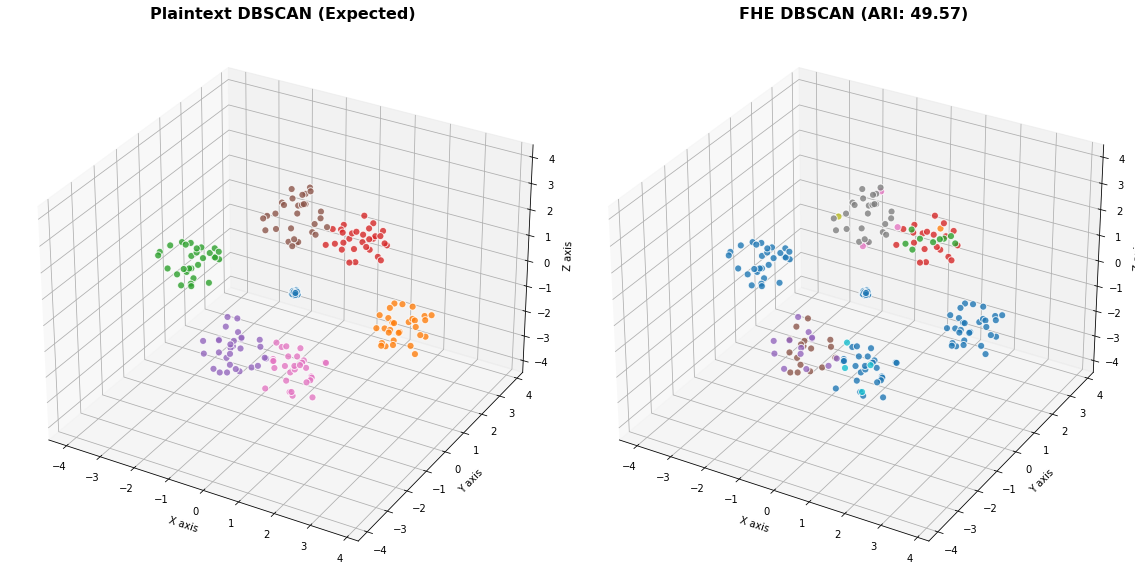

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 파일 경로 설정 (사용자 환경에 맞게 수정하세요)
# ---------------------------------------------------------
ARFF_PATH = "/home/junhyung/study/Data_Analysis_with_CKKS/Cluster/DBSCAN_CKKS/desilo/dataset/Other_cluster/hepta.arff"
CSV_PATH = "/home/junhyung/study/Data_Analysis_with_CKKS/Cluster/DBSCAN_CKKS/desilo/core_test/fhe_clustering_result_1.0_4.0.csv" 

def load_arff_to_pts(filepath):
    pts = []
    data_section = False
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('%'): continue
            if line.lower().startswith('@data'):
                data_section = True
                continue
            if data_section:
                line = line.replace('\t', ' ').replace(',', ' ')
                values = line.split()
                if len(values) < 2: continue
                # 마지막 라벨을 제외한 X, Y, Z 좌표만 추출
                row = [float(v) for v in values[:-1]]
                pts.append(row)
    return np.array(pts, dtype=np.float64)

def main():
    print("데이터 및 결과 파일 로딩 중...")
    
    # 2. 데이터 로드
    pts = load_arff_to_pts(ARFF_PATH)
    df = pd.read_csv(CSV_PATH)
    
    if len(pts) != len(df):
        print("🚨 경고: ARFF 데이터 개수와 CSV 결과 개수가 다릅니다!")
        return

    # X, Y, Z 좌표 분리 (Hepta는 3차원)
    X = pts[:, 0]
    Y = pts[:, 1]
    Z = pts[:, 2]
    
    pt_labels = df['Plaintext_Label'].values
    fhe_labels = df['Rounded_FHE_Label'].values

    # 3. 3D 시각화 설정
    fig = plt.figure(figsize=(16, 8))
    
    # 노이즈(-1)는 검은색(k) 별표(x)로, 나머지는 컬러맵 적용
    cmap = plt.get_cmap('tab20') # 20가지 색상을 지원하는 컬러맵

    # --- [왼쪽 그래프: Plaintext 결과] ---
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.set_title("Plaintext DBSCAN (Expected)", fontsize=16, fontweight='bold')
    
    for label in np.unique(pt_labels):
        idx = pt_labels == label
        if label == -1:
            ax1.scatter(X[idx], Y[idx], Z[idx], c='black', marker='x', s=20, label='Noise(-1)')
        else:
            ax1.scatter(X[idx], Y[idx], Z[idx], cmap=cmap, s=50, alpha=0.8, edgecolors='w')

    ax1.set_xlabel('X axis')
    ax1.set_ylabel('Y axis')
    ax1.set_zlabel('Z axis')

    # --- [오른쪽 그래프: FHE 결과] ---
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.set_title("FHE DBSCAN (ARI: 49.57)", fontsize=16, fontweight='bold')
    
    for label in np.unique(fhe_labels):
        idx = fhe_labels == label
        if label == -1:
            ax2.scatter(X[idx], Y[idx], Z[idx], c='black', marker='x', s=20, label='Noise(-1)')
        else:
            ax2.scatter(X[idx], Y[idx], Z[idx], cmap=cmap, s=50, alpha=0.8, edgecolors='w')

    ax2.set_xlabel('X axis')
    ax2.set_ylabel('Y axis')
    ax2.set_zlabel('Z axis')

    # 4. 출력 및 저장
    plt.tight_layout()
    
    # 이미지로 저장 (보고서/논문용)
    save_filename = "hepta_comparison_plot.png"
    plt.savefig(save_filename, dpi=300)
    print(f"✅ 그래프가 '{save_filename}' 로 저장되었습니다.")
    
    # 화면에 띄우기 (GUI 환경인 경우 마우스로 돌려볼 수 있습니다)
    plt.show()

if __name__ == '__main__':
    main()
